# Task-1

In [101]:
import numpy as np
import matplotlib.pyplot as plt

In [52]:
#backword pass by hand
x = 3.0
w = 1.0
target = 12.0

#x      = input
#w      = weight
#target = correct answer

In [53]:
#forward pass
a = w * x

print("Prediction (a):", a)

Prediction (a): 3.0


In [54]:
#loss function: mean squared error
loss = (a - target) ** 2

print("Loss:", loss)

Loss: 81.0


In [55]:

dloss_da = 2 * (a - target)

print("d(loss)/d(a):", dloss_da)

d(loss)/d(a): -18.0


In [56]:
da_dw = x

print("d(a)/d(w):", da_dw)

d(a)/d(w): 3.0


In [57]:
dloss_dw = dloss_da * da_dw

print("d(loss)/d(w):", dloss_dw)

d(loss)/d(w): -54.0


In [58]:
# Numerical gradient approximation
epsilon = 0.0001

w_plus = w + epsilon

a_plus = w_plus * x
loss_plus = (a_plus - target) ** 2

numerical_gradient = (loss_plus - loss) / epsilon

print("Analytical gradient:", dloss_dw)
print("Numerical gradient:", numerical_gradient)

Analytical gradient: -54.0
Numerical gradient: -53.99909999994179


In [59]:
# Update weight using gradient descent
lr = 0.05

w_new = w - lr * dloss_dw

print("Old weight:", w)
print("Gradient:", dloss_dw)
print("New weight:", w_new)

Old weight: 1.0
Gradient: -54.0
New weight: 3.7


In [60]:
# Update predictions and loss with the new weight
a_new = w_new * x
loss_new = (a_new - target) ** 2

print("New prediction:", a_new)
print("New loss:", loss_new)

New prediction: 11.100000000000001
New loss: 0.8099999999999974


# Task-2

In [61]:
#make a function to calculate gradient descent
def f(x):
    return (x - 5) ** 2

In [62]:
print(f(0))
print(f(5))
print(f(10))

25
0
25


In [63]:

def grad(x):
    return 2 * (x - 5)

In [64]:
print(grad(0))
print(grad(4))
print(grad(5))
print(grad(6))

-10
-2
0
2


In [65]:
def gradient_descent(grad_fn, start, lr, steps):
    x = start
    history = [x]

    for _ in range(steps):
        x = x - lr * grad_fn(x)
        history.append(x)

    return history

In [66]:
start = 0
lr = 0.1

In [67]:
# Run gradient descent for 30 steps
path = gradient_descent(
    grad_fn=grad,
    start=0.0,
    lr=0.1,
    steps=30
)

print("Final position:", path[-1])

Final position: 4.993810299803573


In [68]:
# Plotting the path of gradient descent
print("First six positions:")

for i, x in enumerate(path[:6]):
    print(f"Step {i}: x = {x:.6f}")

First six positions:
Step 0: x = 0.000000
Step 1: x = 1.000000
Step 2: x = 1.800000
Step 3: x = 2.440000
Step 4: x = 2.952000
Step 5: x = 3.361600


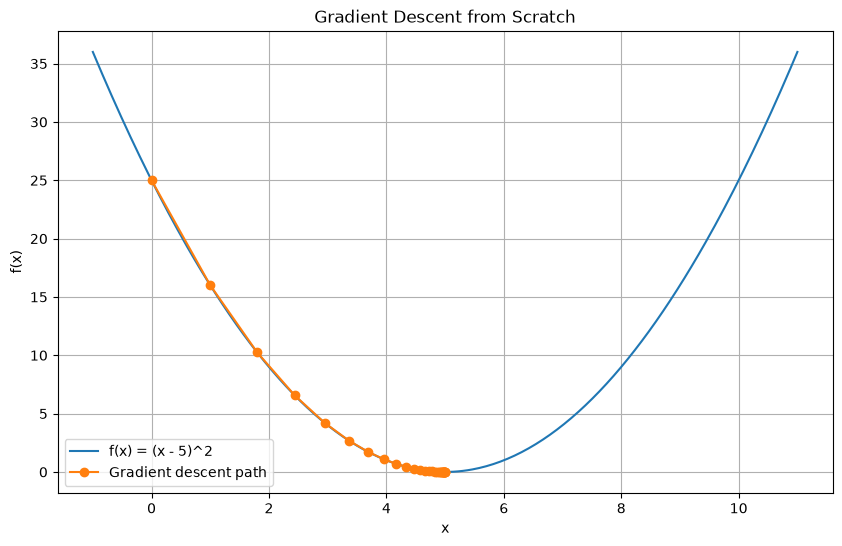

In [69]:
x_values = np.linspace(-1, 11, 300)
y_values = f(x_values)

plt.figure(figsize=(10, 6))

plt.plot(x_values, y_values, label="f(x) = (x - 5)^2")

path_y = [f(x) for x in path]

plt.plot(
    path,
    path_y,
    "o-",
    label="Gradient descent path"
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent from Scratch")
plt.legend()
plt.grid(True)

plt.show()

In [100]:
print(f"Started at: {path[0]:.4f}")
print(f"Ended at:   {path[-1]:.4f}")
print("Minimum:    5.0000")

Started at: 2.2000
Ended at:   1.3885
Minimum:    5.0000


In [71]:
print("Final x:", path[-1])
print("Final function value:", f(path[-1]))

Final x: 4.993810299803573
Final function value: 3.83123885216492e-05


In [72]:
def f2(x):
    return (x + 3) ** 2

In [73]:
def grad2(x):
    return 2 * (x + 3)

In [74]:
path2 = gradient_descent(
    grad_fn=grad2,
    start=5.0,
    lr=0.1,
    steps=30
)

print("Second function")
print("Started at:", path2[0])
print("Ended at:", path2[-1])
print("Known minimum: -3")

Second function
Started at: 5.0
Ended at: -2.9900964796857172
Known minimum: -3


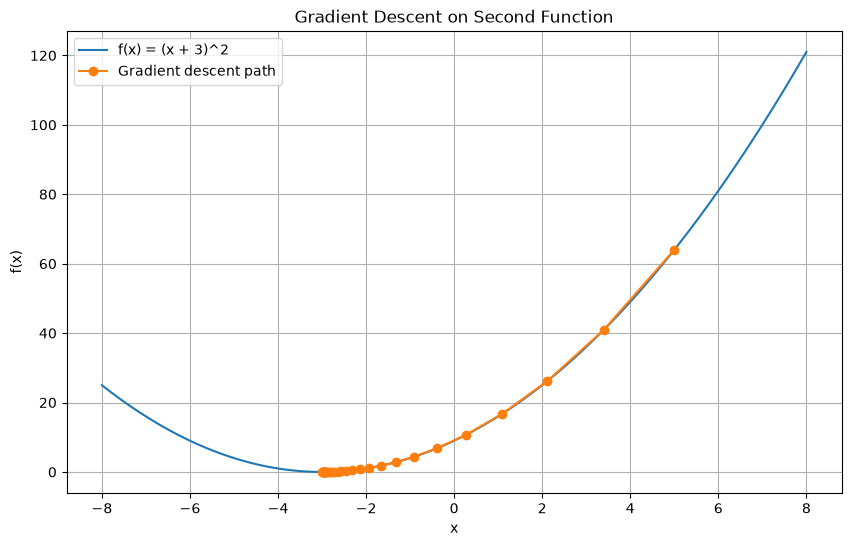

In [75]:
x_values2 = np.linspace(-8, 8, 300)
y_values2 = f2(x_values2)

path2_y = [f2(x) for x in path2]

plt.figure(figsize=(10, 6))

plt.plot(
    x_values2,
    y_values2,
    label="f(x) = (x + 3)^2"
)

plt.plot(
    path2,
    path2_y,
    "o-",
    label="Gradient descent path"
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent on Second Function")
plt.legend()
plt.grid(True)

plt.show()

# Task-3

In [76]:
def f(x):
    return (x - 5) ** 2

In [77]:
def grad(x):
    return 2 * (x - 5)

In [78]:
def gradient_descent(grad_fn, start, lr, steps):
    x = start
    history = [x]

    for _ in range(steps):
        x = x - lr * grad_fn(x)
        history.append(x)

    return history

In [79]:
learning_rates = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.05]

for lr in learning_rates:
    path = gradient_descent(
        grad_fn=grad,
        start=0.0,
        lr=lr,
        steps=60
    )

    print(f"lr = {lr:<5} -> final x = {path[-1]}")

lr = 0.001 -> final x = 0.5659306472654195
lr = 0.01  -> final x = 3.512234286539396
lr = 0.1   -> final x = 4.999992337522295
lr = 0.5   -> final x = 5.0
lr = 0.9   -> final x = 4.999992337522295
lr = 1.0   -> final x = 0.0
lr = 1.05  -> final x = -1517.4081977070985


In [80]:
test_rates = [0.9, 0.99, 1.0, 1.01, 1.05]

for lr in test_rates:
    path = gradient_descent(
        grad_fn=grad,
        start=0.0,
        lr=lr,
        steps=20
    )

    print(f"lr = {lr} -> final x = {path[-1]:.4f}")

lr = 0.9 -> final x = 4.9424
lr = 0.99 -> final x = 1.6620
lr = 1.0 -> final x = 0.0000
lr = 1.01 -> final x = -2.4297
lr = 1.05 -> final x = -28.6375


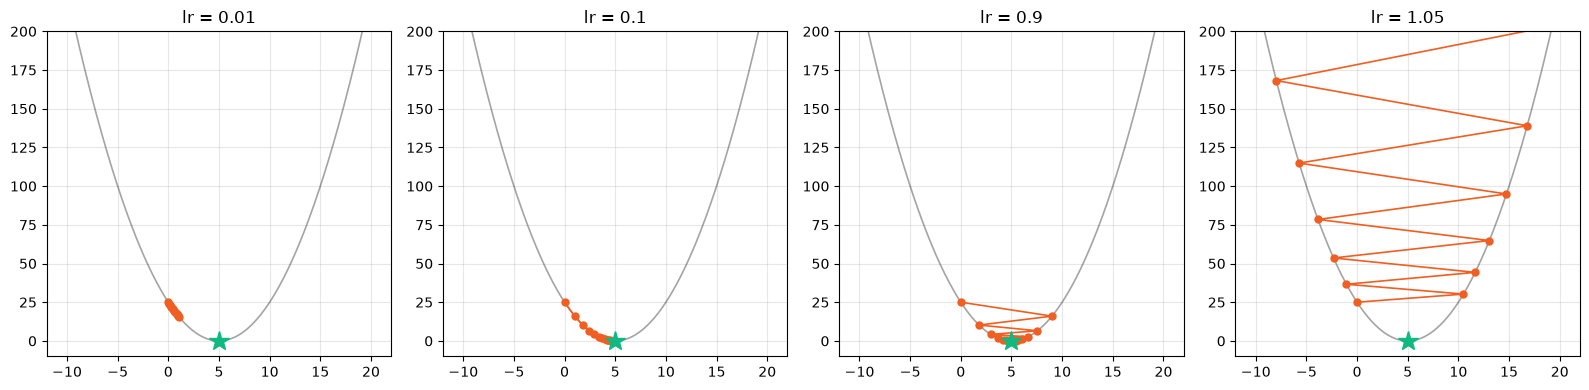

In [81]:
# Look at the actual paths
# The shapes tell the story

w_range = np.linspace(-12, 22, 500)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, lr_try in zip(axes, [0.01, 0.1, 0.9, 1.05]):

    # Gradient descent starts from x = 0
    p = gradient_descent(grad, 0.0, lr_try, 12)

    # Keep the diverging path on screen
    p_safe = np.clip(p, -15, 25)

    # Draw the function
    ax.plot(
        w_range,
        f(w_range),
        color="#1A1D1D",
        linewidth=1.2,
        alpha=0.4
    )

    # Draw gradient descent path
    ax.plot(
        p_safe,
        f(p_safe),
        "o-",
        color="#F05E22",
        markersize=5,
        linewidth=1.2
    )

    # Mark the minimum point
    ax.plot(
        5,
        0,
        "*",
        color="#10B981",
        markersize=15
    )

    # Title
    ax.set_title(f"lr = {lr_try}")

    # Same view for all graphs
    ax.set_ylim(-10, 200)
    ax.set_xlim(-12, 22)

    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Task-4

In [82]:
# Non-convex function
def f(x):
    return x**4 - 4*x**2 + 0.4*x

In [83]:
# Gradient of the function
def grad(x):
    return 4*x**3 - 8*x + 0.4


In [84]:
# Gradient Descent
def gradient_descent(start, lr, steps):
    x = start
    history = [x]

    for _ in range(steps):
        x = x - lr * grad(x)
        history.append(x)

    return np.array(history)


In [85]:
# Starting points
starts = [-2, -0.5, 0.5, 2.2]

In [86]:
# Learning rate
lr = 0.01

In [87]:
# Number of steps
steps = 200

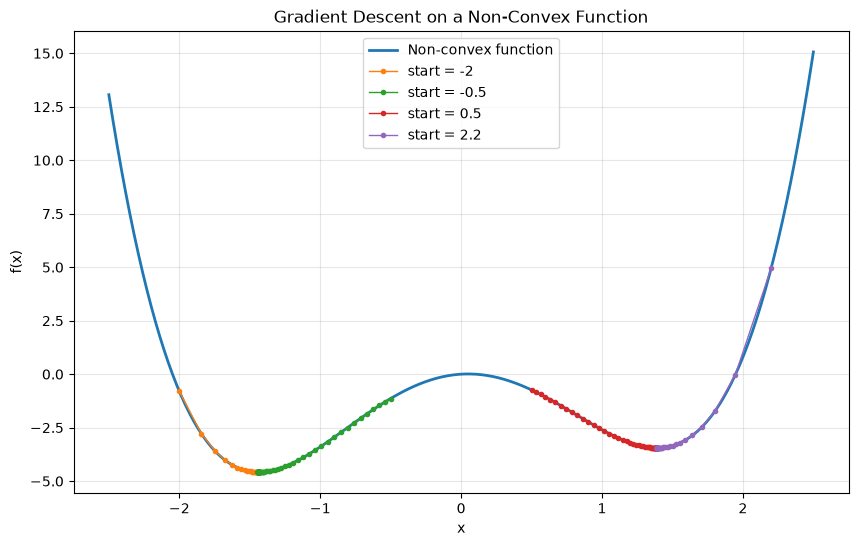

In [88]:
# Plot the function
x_range = np.linspace(-2.5, 2.5, 500)

plt.figure(figsize=(10, 6))

plt.plot(
    x_range,
    f(x_range),
    linewidth=2,
    label="Non-convex function"
)


# Run Gradient Descent from each starting point
for start in starts:

    path = gradient_descent(start, lr, steps)

    plt.plot(
        path,
        f(path),
        "o-",
        markersize=3,
        linewidth=1,
        label=f"start = {start}"
    )


plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent on a Non-Convex Function")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

# Task-5

In [89]:
# Function
def f2(w1, w2):
    return (w1 - 2)**2 + 3*(w2 + 1)**2

In [90]:
# Gradient
def grad2(w1, w2):
    return np.array([
        2*(w1 - 2),
        6*(w2 + 1)
    ])

In [91]:
# Gradient Descent
def gradient_descent_2d(start, lr, steps):

    point = np.array(start, dtype=float)

    history = [point.copy()]

    for _ in range(steps):

        gradient = grad2(point[0], point[1])

        point = point - lr * gradient

        history.append(point.copy())

    return np.array(history)

In [92]:
# Starting point
start = [4, 4]

# Learning rate
lr = 0.1

# Number of steps
steps = 30

In [93]:
# Run Gradient Descent
path2d = gradient_descent_2d(start, lr, steps)

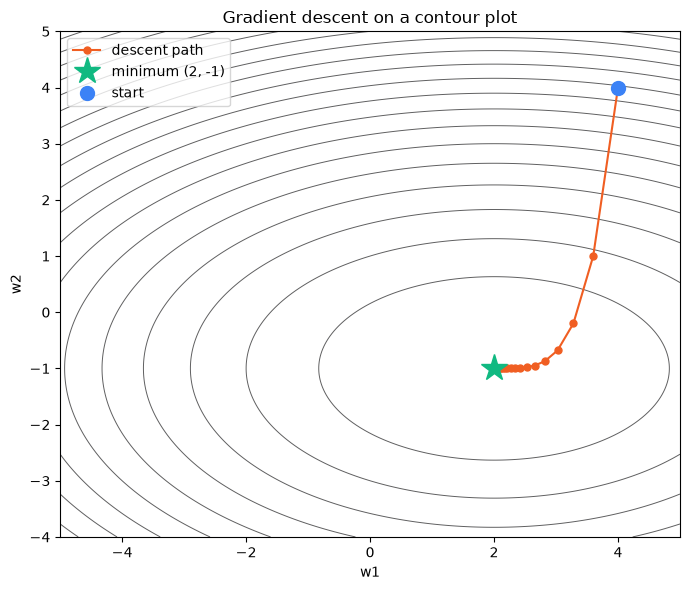

In [94]:
# draw the descent path on a contour plot
w1_grid, w2_grid = np.meshgrid(
    np.linspace(-5, 5, 200),
    np.linspace(-4, 5, 200)
)

z = f2(w1_grid, w2_grid)


fig, ax = plt.subplots(figsize=(7, 6))

contours = ax.contour(
    w1_grid,
    w2_grid,
    z,
    levels=20,
    colors="#5F5F60",
    linewidths=0.7
)

ax.plot(
    path2d[:, 0],
    path2d[:, 1],
    "o-",
    color="#F05E22",
    markersize=5,
    linewidth=1.5,
    label="descent path"
)

ax.plot(
    2,
    -1,
    "*",
    color="#10B981",
    markersize=20,
    label="minimum (2, -1)"
)

ax.plot(
    path2d[0, 0],
    path2d[0, 1],
    "o",
    color="#3B82F6",
    markersize=10,
    label="start"
)

ax.set_xlabel("w1")
ax.set_ylabel("w2")

ax.set_title("Gradient descent on a contour plot")

ax.legend()

plt.tight_layout()
plt.show()

# Task-6

In [95]:
# Non-convex function
def f(x):
    return x**4 - 4*x**2 + 0.4*x

In [96]:
# Gradient
def grad(x):
    return 4*x**3 - 8*x + 0.4

In [97]:
# Normal Gradient Descent
def gradient_descent(start, lr, steps):

    x = start
    history = [x]

    for _ in range(steps):

        x = x - lr * grad(x)

        history.append(x)

    return np.array(history)

In [98]:
# Gradient Descent with Momentum
def momentum_descent(start, lr, beta, steps):

    x = start

    # Initial velocity
    v = 0

    history = [x]

    for _ in range(steps):

        # Update velocity
        v = beta * v - lr * grad(x)

        # Update position
        x = x + v

        history.append(x)

    return np.array(history)


# Settings
start = 2.2
lr = 0.01
beta = 0.9
steps = 200


# Run both methods
normal_path = gradient_descent(start, lr, steps)

momentum_path = momentum_descent(
    start,
    lr,
    beta,
    steps
)

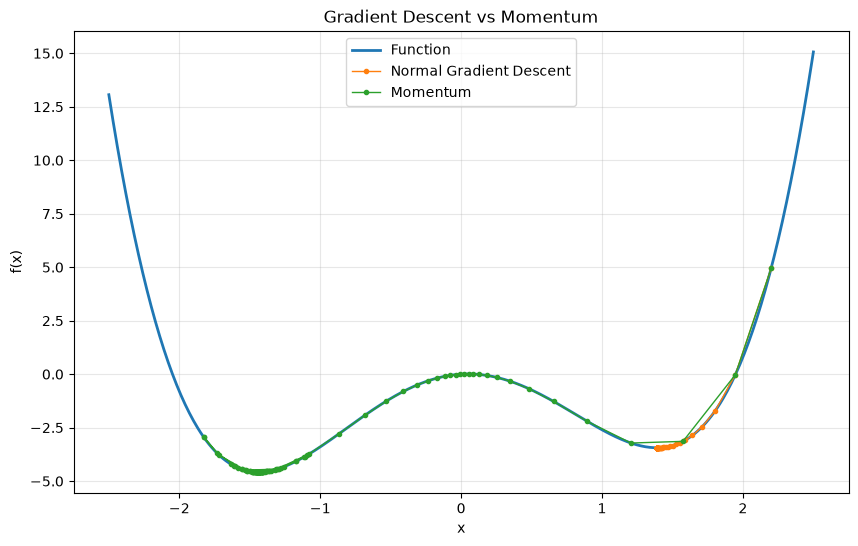

In [99]:
# Plot function
x_range = np.linspace(-2.5, 2.5, 500)

plt.figure(figsize=(10, 6))

plt.plot(
    x_range,
    f(x_range),
    linewidth=2,
    label="Function"
)

# Normal Gradient Descent
plt.plot(
    normal_path,
    f(normal_path),
    "o-",
    markersize=3,
    linewidth=1,
    label="Normal Gradient Descent"
)

# Momentum
plt.plot(
    momentum_path,
    f(momentum_path),
    "o-",
    markersize=3,
    linewidth=1,
    label="Momentum"
)


plt.xlabel("x")
plt.ylabel("f(x)")

plt.title("Gradient Descent vs Momentum")

plt.grid(alpha=0.3)
plt.legend()

plt.show()